# Evaluating small_llm

Inspect a training run: plot losses, compute perplexity on the val split, and generate samples.

Set `OUT_DIR` to the `--out_dir` you trained with (e.g. `out/shakespeare`)
and `DATA_DIR` to the corresponding `--data_dir` (e.g. `data/shakespeare`).

In [1]:
import json, os, pickle
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import optax
import tiktoken

from small_llm.llm import LLM, ModelConfig, SampleConfig
from small_llm.data import DataLoader, ensure_bin

OUT_DIR = 'out/shakespeare'
DATA_DIR = 'data/shakespeare'

/Users/mariana/Documents/projects/pierre/small_llm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Loss curves

Read `metrics.jsonl` (one JSON record per log line) and plot train / val loss vs. step.

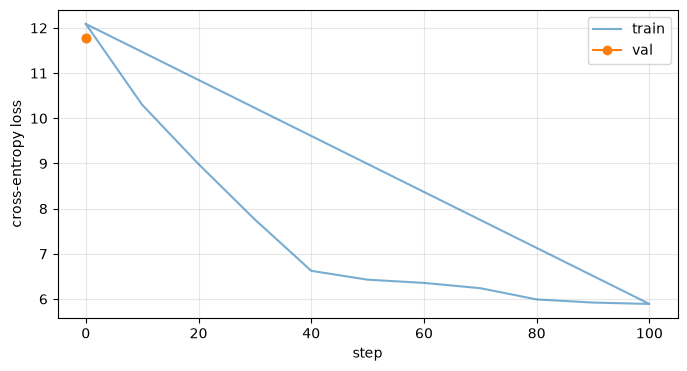

best val_loss = 11.7819  @ step 0   (ppl = 130867.14)


In [2]:
records = [json.loads(l) for l in open(os.path.join(OUT_DIR, 'metrics.jsonl'))]
train = [(r['step'], r['train_loss']) for r in records if 'train_loss' in r]
val   = [(r['step'], r['val_loss'])   for r in records if 'val_loss'   in r]

fig, ax = plt.subplots(figsize=(8, 4))
if train:
    ts, ls = zip(*train); ax.plot(ts, ls, label='train', alpha=0.6)
if val:
    ts, ls = zip(*val);   ax.plot(ts, ls, label='val',   marker='o')
ax.set_xlabel('step'); ax.set_ylabel('cross-entropy loss'); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

if val:
    best = min(val, key=lambda r: r[1])
    print(f'best val_loss = {best[1]:.4f}  @ step {best[0]}   (ppl = {np.exp(best[1]):.2f})')

In [3]:
records

[{'step': 0,
  'train_loss': 12.088350296020508,
  'lr': 0.0,
  'time': 6.268533945083618},
 {'step': 0, 'val_loss': 11.78193787574768},
 {'step': 10,
  'train_loss': 10.299107551574707,
  'lr': 0.00010000000474974513,
  'time': 127.83571195602417},
 {'step': 20,
  'train_loss': 8.987017631530762,
  'lr': 0.00020000000949949026,
  'time': 155.16736888885498},
 {'step': 30,
  'train_loss': 7.759607791900635,
  'lr': 0.0003000000142492354,
  'time': 257.5579619407654},
 {'step': 40,
  'train_loss': 6.624026775360107,
  'lr': 0.0004000000189989805,
  'time': 4237.981374979019},
 {'step': 50,
  'train_loss': 6.427868843078613,
  'lr': 0.0005000000237487257,
  'time': 11189.203950166702},
 {'step': 60,
  'train_loss': 6.356235504150391,
  'lr': 0.0006000000284984708,
  'time': 18506.73820209503},
 {'step': 70,
  'train_loss': 6.239456653594971,
  'lr': 0.0007000000332482159,
  'time': 23263.22563791275},
 {'step': 80,
  'train_loss': 5.99042272567749,
  'lr': 0.000800000037997961,
  'time':

## 2. Load checkpoint

In [ ]:
ckpt = pickle.load(open(os.path.join(OUT_DIR, 'ckpt.pkl'), 'rb'))
raw_cfg = dict(ckpt['config'])
raw_cfg['sample_config'] = SampleConfig(**raw_cfg['sample_config'])
cfg = ModelConfig(**raw_cfg)

llm = LLM(cfg)
llm.model_state = llm.model_state.replace(params=ckpt['params'])
print(f'loaded step={ckpt["step"]}  saved val_loss={ckpt.get("val_loss")}')

## 3. Full val loss + perplexity

Average over many random val batches for a tight estimate.

In [ ]:
val_bin = ensure_bin(DATA_DIR, 'val')
val_loader = DataLoader(val_bin, batch_size=32, block_size=cfg.max_len, seed=0)

@jax.jit
def eval_step(params, batch):
    x, y = batch[:, :-1], batch[:, 1:]
    logits = llm.model.apply(params, x, training=False)
    return optax.softmax_cross_entropy_with_integer_labels(logits, y).mean()

losses = [float(eval_step(llm.model_state.params, next(val_loader))) for _ in range(200)]
val_loss = float(np.mean(losses))
print(f'val_loss = {val_loss:.4f}    perplexity = {np.exp(val_loss):.2f}')

## 4. Generate samples

Tokenize a prompt with tiktoken gpt2 and sample `max_new_tokens` more tokens.

In [ ]:
enc = tiktoken.get_encoding('gpt2')
prompt_text = 'ROMEO:'
prompt_ids = enc.encode_ordinary(prompt_text)
prompt = jnp.asarray([prompt_ids], dtype=jnp.int32)

out = llm.generate(prompt)
print(enc.decode(np.asarray(out[0]).tolist()))